# 🎓 Student Career Recommendation System Using Artificial Intelligence

## 📌 Project Overview

This project is an AI-based career recommendation system that predicts suitable career paths for students based on their academic background, skills, interests, personality, and preferences.

## 🚀 Objectives

- Analyze student profiles using Machine Learning
- Recommend suitable career options
- Compare multiple classification algorithms
- Select the best performing model
- Deploy the final model as a web application

## 🛠️ Technologies Used

- Python
- Pandas & NumPy
- Scikit-learn
- Streamlit
- Joblib

## 🔄 Project Workflow

Student Data  
⬇️  
Data Preprocessing  
⬇️  
Exploratory Data Analysis  
⬇️  
Machine Learning Model Training  
⬇️  
Model Evaluation & Selection  
⬇️  
Career Prediction System

## 🤖 Machine Learning Approach

This is a **Classification Problem** where the model predicts a career category from student features.

Models Tested:
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- KNN

Final Model:
✅ Random Forest Classifier

# 1. Environment Setup & Import Required Libraries

Before starting the project, a separate Python environment was created to manage project dependencies and maintain a clean development setup.

In this step, we import the required Python libraries used for:

- Data loading and manipulation
- Data visualization and exploratory data analysis
- Data preprocessing
- Machine Learning model development
- Model evaluation
- Saving and loading trained models

In [ ]:
import warnings  ### Importing few starting libraries
warnings.filterwarnings('ignore')
import re
import json
import datetime
import csv
import pandas as pd 
import random
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the data and EDA and visualisation

In [3]:
# Load dataset and check basic information

df=pd.read_csv("student_career_dataset.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Dataset Shape:
(5550, 23)

Columns:
Index(['Student_ID', 'Age', '10th_Percentage', '12th_Percentage',
       '12th_Stream', 'Degree', 'CGPA', 'Programming', 'Communication',
       'Leadership', 'Creativity', 'Problem_Solving', 'Technology_Interest',
       'Medical_Interest', 'Finance_Interest', 'Government_Interest',
       'Business_Interest', 'Teaching_Interest', 'Law_Interest',
       'Physical_Fitness', 'Personality', 'Hobby', 'Career'],
      dtype='str')

Information:
<class 'pandas.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           5550 non-null   int64  
 1   Age                  5550 non-null   int64  
 2   10th_Percentage      5550 non-null   int64  
 3   12th_Percentage      5550 non-null   int64  
 4   12th_Stream          5550 non-null   str    
 5   Degree               5550 non-null   str    
 6   CGPA              

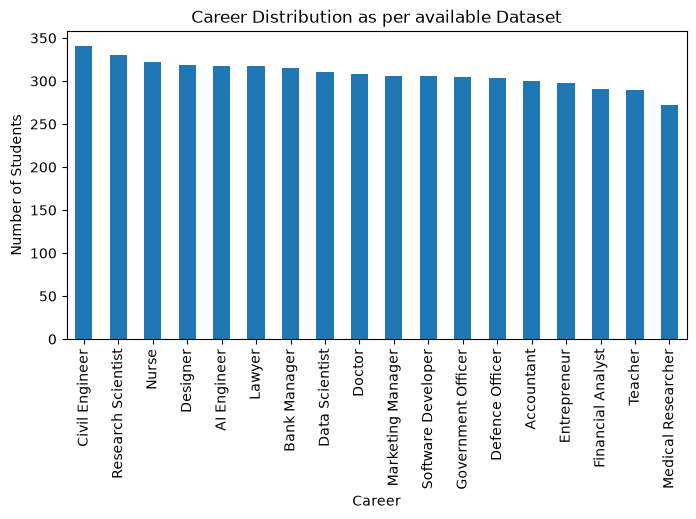

In [7]:
# Visualize the distribution of careers in the dataset

plt.figure(figsize=(8,4))

df["Career"].value_counts().plot(
    kind="bar"
)

plt.title("Career Distribution as per available Dataset")
plt.xlabel("Career")
plt.ylabel("Number of Students")
plt.xticks(rotation=90)

plt.show()

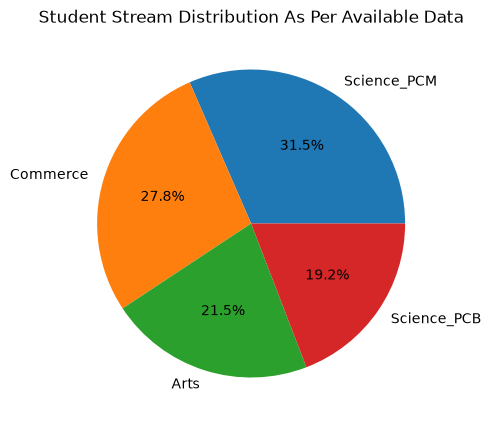

In [6]:
plt.figure(figsize=(7,5))

df["12th_Stream"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Student Stream Distribution As Per Available Data")

plt.ylabel("")

plt.show()

<Figure size 1000x600 with 0 Axes>

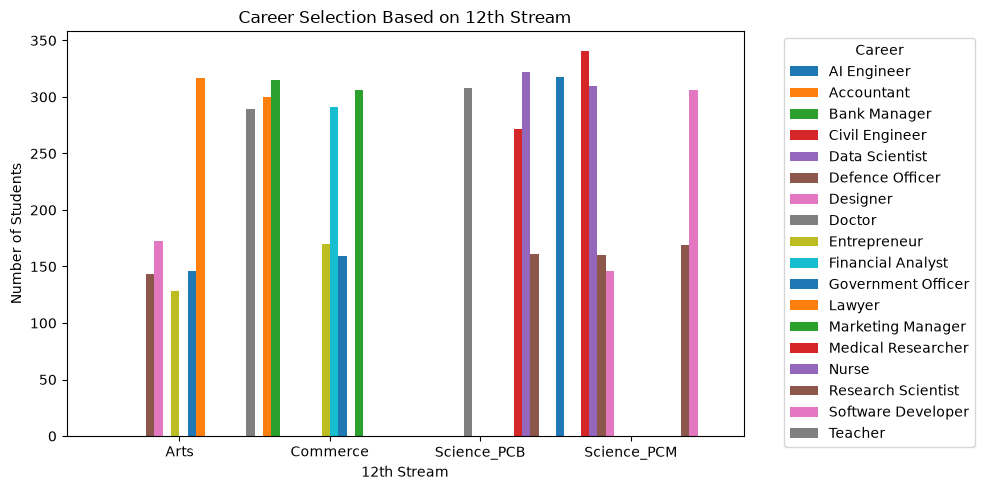

In [11]:
plt.figure(figsize=(10,6))

career_stream = pd.crosstab(
    df["12th_Stream"],
    df["Career"]
)

career_stream.plot(
    kind="bar",
    figsize=(10,5),
    width=1
)

plt.title("Career Selection Based on 12th Stream")
plt.xlabel("12th Stream")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.legend(
    title="Career",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

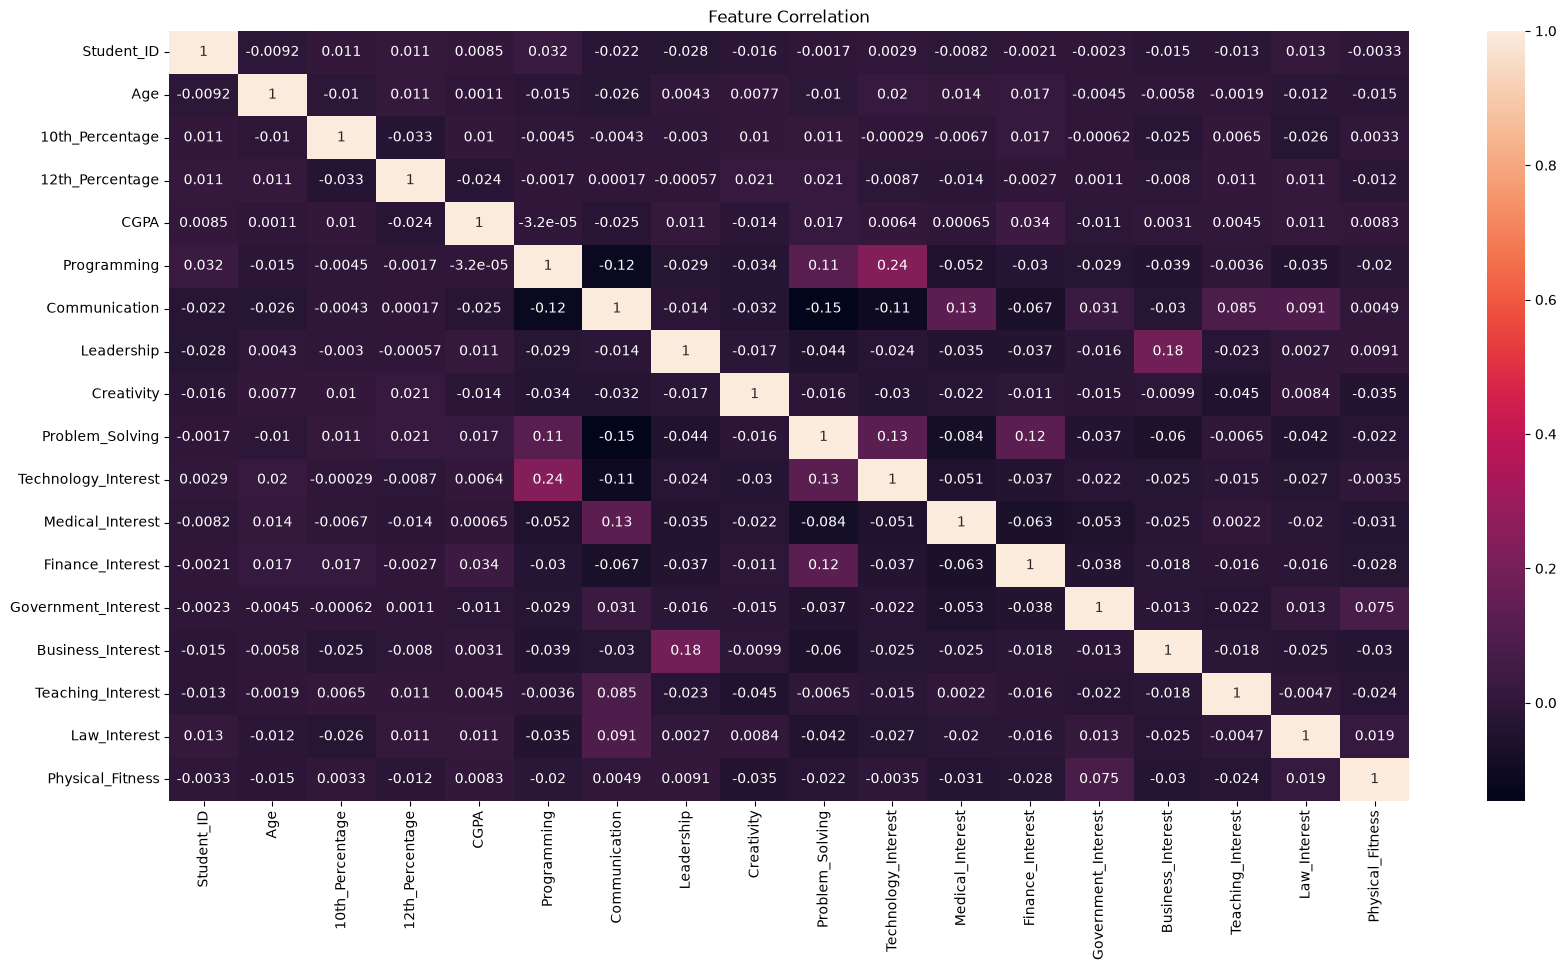

In [14]:
plt.figure(figsize=(20,10))
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)
sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.title("Feature Correlation")
plt.show()

## 3. Training models and saving the model

In [15]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders={}

categorical_columns=[
"12th_Stream",
"Degree",
"Personality",
"Hobby",
"Career"
]

for col in categorical_columns:
    encoders[col]=LabelEncoder()
    df[col]=encoders[col].fit_transform(df[col])

joblib.dump(encoders,"encoders.pkl")

print("Encoder saved")

Encoder saved


In [16]:
X=df.drop("Career",axis=1)
y=df["Career"]

In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:",X_train.shape)
print("Testing Data:",X_test.shape)

Training Data: (4440, 22)
Testing Data: (1110, 22)


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report

dt_model=DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred=dt_model.predict(
    X_test
)

dt_accuracy=accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:",dt_accuracy)

Decision Tree Accuracy: 0.7396396396396396


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred=rf_model.predict(
    X_test
)

rf_accuracy=accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",rf_accuracy)

Random Forest Accuracy: 0.7864864864864864


In [20]:
from sklearn.ensemble import ExtraTreesClassifier

et_model=ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

et_model.fit(
    X_train,
    y_train
)

et_pred=et_model.predict(
    X_test
)

et_accuracy=accuracy_score(
    y_test,
    et_pred
)

print("Extra Trees Accuracy:",et_accuracy)

Extra Trees Accuracy: 0.7783783783783784


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model=GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred=gb_model.predict(
    X_test
)

gb_accuracy=accuracy_score(
    y_test,
    gb_pred
)

print("Gradient Boosting Accuracy:",gb_accuracy)

Gradient Boosting Accuracy: 0.7756756756756756


In [22]:
results=pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        et_accuracy,
        gb_accuracy
    ]
})

results["Accuracy"]=results["Accuracy"]*100

results=results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

               Model   Accuracy
1      Random Forest  78.648649
2        Extra Trees  77.837838
3  Gradient Boosting  77.567568
0      Decision Tree  73.963964


### As per models accuracy we can conclude that random forest is giving good reslts. So we are just saving it and we will use it for our prediction. 

In [23]:
from sklearn.ensemble import RandomForestClassifier
import joblib

final_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

final_model.fit(
    X_train,
    y_train
)

joblib.dump(
    final_model,
    "career_prediction_model.pkl",
    compress=3
)

print("Saved")

Saved


# Conclusion

The final trained machine learning model was saved as a `.pkl` file for future use and deployment.

This allows the trained model to be loaded directly into applications without retraining.

The complete workflow included:

- Dataset preparation
- Exploratory Data Analysis
- Data preprocessing
- Model training
- Model comparison
- Model evaluation
- Saving the final career prediction model

The saved model was later integrated with a Streamlit application to provide real-time career recommendations for students.